In [1]:
# Install Dependencies

!pip install osmnx folium scipy shapely scikit-learn xgboost \
             fastapi uvicorn pydantic pyproj --quiet
print("All libraries installed.")

All libraries installed.


In [2]:
# All Imports

import os, math, json, random, warnings, time, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import osmnx as ox
import folium
from folium.plugins import AntPath
from shapely.geometry import Point, LineString
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from sklearn.metrics import (
    confusion_matrix, precision_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
from collections import defaultdict

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

for d in ["data/graphs","outputs/maps","outputs/models","outputs/reports"]:
    os.makedirs(d, exist_ok=True)

print("Imports OK.")

Imports OK.


In [3]:
# Global Configuration  (3 cities)

CITY_CONFIGS = {
    "Chennai": {
        "name":              "Chennai, Tamil Nadu, India",
        "center":            [13.0827, 80.2707],
        "zoom":              13,
        "graph_path":        "data/graphs/chennai_drive.graphml",
        "n_normal_oneway":   120,
        "n_wrong_way":        40,
        "n_normal_twoway":    15,
        "n_stationary":        8,
        "n_intersection":      8,
        "n_uturn":             5,          # NEW: U-turn scenarios
        "stationary_anchors": [
            (13.0827,80.2707),(13.0674,80.2376),(13.0500,80.2121),
            (13.0900,80.2785),(13.0750,80.2600),(13.0600,80.2500),
            (13.0850,80.2650),(13.0700,80.2450),
        ],
    },
    "Bengaluru": {
        "name":              "Bengaluru, Karnataka, India",
        "center":            [12.9716, 77.5946],
        "zoom":              13,
        "graph_path":        "data/graphs/bengaluru_drive.graphml",
        "n_normal_oneway":   120,
        "n_wrong_way":        40,
        "n_normal_twoway":    15,
        "n_stationary":        8,
        "n_intersection":      8,
        "n_uturn":             5,
        "stationary_anchors": [
            (12.9716,77.5946),(12.9800,77.6000),(12.9600,77.5800),
            (12.9900,77.6100),(12.9500,77.5700),(12.9650,77.5850),
            (12.9750,77.5950),(12.9850,77.6050),
        ],
    },
    "Hyderabad": {
        "name":              "Hyderabad, Telangana, India",
        "center":            [17.3850, 78.4867],
        "zoom":              13,
        "graph_path":        "data/graphs/hyderabad_drive.graphml",
        "n_normal_oneway":   120,
        "n_wrong_way":        40,
        "n_normal_twoway":    15,
        "n_stationary":        8,
        "n_intersection":      8,
        "n_uturn":             5,
        "stationary_anchors": [
            (17.3850,78.4867),(17.3900,78.4900),(17.3800,78.4800),
            (17.3950,78.4950),(17.3750,78.4750),(17.3820,78.4820),
            (17.3880,78.4880),(17.3760,78.4760),
        ],
    },
}

# Detection thresholds
MIN_SPEED_KMH            = 5
MAX_SPEED_MS             = 55
ALERT_CONSECUTIVE_SEC    = 3
INTERSECTION_BUFFER_M    = 30
SNAP_MAX_DIST_DEG        = 0.0015

# Simulation parameters
GPS_NOISE_DEG     = 0.00004
POINTS_PER_TRACE  = 30
GAP_THRESHOLD_SEC = 5
SG_WINDOW         = 7       # Savitzky-Golay window (must be odd)
SG_POLY           = 3       # Savitzky-Golay polynomial order
RANSAC_THRESH_DEG = 0.0004  # GPS outlier threshold for RANSAC

EXCLUDED_ROAD_TYPES = {
    "service","motorway_link","trunk_link","primary_link","secondary_link",
}
ALL_CITIES = list(CITY_CONFIGS.keys())

total_veh = sum(
    c["n_normal_oneway"]+c["n_wrong_way"]+c["n_normal_twoway"]+
    c["n_stationary"]+c["n_intersection"]+c["n_uturn"]
    for c in CITY_CONFIGS.values()
)
print(f" Config loaded | Cities: {ALL_CITIES}")
print(f"  Total vehicles: {total_veh}  (target: 500+)")



 Config loaded | Cities: ['Chennai', 'Bengaluru', 'Hyderabad']
  Total vehicles: 588  (target: 500+)


In [4]:
# Core Math Utilities

def calculate_bearing(lat1, lon1, lat2, lon2):
    dl   = math.radians(lon2-lon1)
    la1  = math.radians(lat1)
    la2  = math.radians(lat2)
    x    = math.sin(dl)*math.cos(la2)
    y    = math.cos(la1)*math.sin(la2) - math.sin(la1)*math.cos(la2)*math.cos(dl)
    return (math.degrees(math.atan2(x, y))+360) % 360

def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6_371_000
    p1,p2= math.radians(lat1), math.radians(lat2)
    dp   = math.radians(lat2-lat1)
    dl   = math.radians(lon2-lon1)
    a    = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R*2*math.atan2(math.sqrt(a), math.sqrt(1-a))

def angular_difference(b1, b2):
    d = abs(b1-b2) % 360
    return d if d <= 180 else 360-d

def bearing_from_geometry(geom):
    c = list(geom.coords)
    lon1,lat1 = c[0]; lon2,lat2 = c[-1]
    return calculate_bearing(lat1,lon1,lat2,lon2)

def get_local_road_bearing(lat, lon, road_geom):
    vp   = Point(lon, lat)
    pd_  = road_geom.project(vp)
    sl   = road_geom.length
    d1   = max(0, pd_-5)
    d2   = min(sl, pd_+5)
    if d2-d1 < 1e-9:
        c = list(road_geom.coords)
        return calculate_bearing(c[0][1],c[0][0],c[-1][1],c[-1][0])
    p1   = road_geom.interpolate(d1)
    p2   = road_geom.interpolate(d2)
    return calculate_bearing(p1.y,p1.x,p2.y,p2.x)

def heading_change_rate(bearings):
    """Degrees/second change — used for U-turn detection."""
    if len(bearings) < 2:
        return 0.0
    diffs = [angular_difference(bearings[i], bearings[i-1])
             for i in range(1, len(bearings))]
    return float(np.mean(diffs))

assert angular_difference(10,350) == 20
assert angular_difference(90,270) == 180
assert haversine_m(0,0,0,1) > 111_000
print(" Math utilities OK.")



 Math utilities OK.


In [5]:
# Layer 1: Kalman Filter GPS Smoother

class KalmanGPSSmoother:
    """1-D Kalman applied independently to lat and lon."""
    def __init__(self, process_noise=1e-5, measurement_noise=1e-4):
        self.Q, self.R = process_noise, measurement_noise

    def filter_1d(self, obs):
        x, P, out = obs[0], 1.0, []
        for z in obs:
            Pp = P + self.Q
            K  = Pp / (Pp + self.R)
            x  = x + K*(z-x)
            P  = (1-K)*Pp
            out.append(x)
        return out

    def smooth(self, lats, lons):
        return self.filter_1d(lats), self.filter_1d(lons)

print("Layer 1 — Kalman Filter defined.")



Layer 1 — Kalman Filter defined.


In [6]:
# Layer 2: RANSAC GPS Outlier Rejection

def ransac_gps_filter(lats, lons, threshold_deg=RANSAC_THRESH_DEG,
                      n_iter=50, min_inlier_ratio=0.6):
    """
    RANSAC: iteratively fit a linear lat/lon trend, reject outliers
    beyond `threshold_deg` from the consensus line.
    Falls back gracefully if not enough points.
    """
    n = len(lats)
    if n < 4:
        return lats, lons

    best_mask = np.ones(n, dtype=bool)
    best_score = 0
    coords = np.column_stack([lats, lons])

    for _ in range(n_iter):
        idx = np.random.choice(n, 2, replace=False)
        p1, p2 = coords[idx[0]], coords[idx[1]]
        d = p2 - p1
        norm = np.linalg.norm(d)
        if norm < 1e-10:
            continue
        # Distance from each point to the line p1→p2
        dists = np.abs(np.cross(d, p1 - coords)) / norm
        mask  = dists < threshold_deg
        score = mask.sum()
        if score > best_score and score/n >= min_inlier_ratio:
            best_score = score
            best_mask  = mask

    # Replace outliers with linear interpolation of neighbours
    clean_lats = np.array(lats, dtype=float)
    clean_lons = np.array(lons, dtype=float)
    outlier_idx = np.where(~best_mask)[0]
    for i in outlier_idx:
        prev_i = max(0, i-1)
        next_i = min(n-1, i+1)
        clean_lats[i] = (clean_lats[prev_i]+clean_lats[next_i])/2
        clean_lons[i] = (clean_lons[prev_i]+clean_lons[next_i])/2

    return clean_lats.tolist(), clean_lons.tolist()

print(f"Layer 2 — RANSAC Outlier Rejection defined "
      f"(threshold={RANSAC_THRESH_DEG}°).")


Layer 2 — RANSAC Outlier Rejection defined (threshold=0.0004°).


In [7]:
# Layer 3: Savitzky-Golay Bearing Smoother

def savitzky_golay_bearing_smooth(bearings, window=SG_WINDOW, poly=SG_POLY):
    """
    Savitzky-Golay filter on bearings via sin/cos decomposition
    to handle the 0/360 wraparound correctly.
    """
    n = len(bearings)
    if n < window:
        return bearings          # not enough points — return as-is
    sins = np.array([math.sin(math.radians(b)) for b in bearings])
    coss = np.array([math.cos(math.radians(b)) for b in bearings])
    sm_s = savgol_filter(sins, window_length=window, polyorder=poly)
    sm_c = savgol_filter(coss, window_length=window, polyorder=poly)
    return [math.degrees(math.atan2(s, c)) % 360
            for s, c in zip(sm_s, sm_c)]

def circular_moving_average(bearings, window=5):
    out = []
    for i in range(len(bearings)):
        sl   = bearings[max(0, i-window+1):i+1]
        sm   = np.mean([math.sin(math.radians(b)) for b in sl])
        cm   = np.mean([math.cos(math.radians(b)) for b in sl])
        out.append(math.degrees(math.atan2(sm, cm)) % 360)
    return out

print(f"Layer 3 — Savitzky-Golay Bearing Smoother defined "
      f"(window={SG_WINDOW}, poly={SG_POLY}).")



Layer 3 — Savitzky-Golay Bearing Smoother defined (window=7, poly=3).


In [8]:
#  OSM Graph Loader

def load_city_graph(city_key):
    cfg  = CITY_CONFIGS[city_key]
    path = cfg["graph_path"]
    if os.path.exists(path):
        G = ox.load_graphml(path)
        print(f"  [{city_key}] Loaded from cache.")
    else:
        print(f"  [{city_key}] Downloading from OSM (first run only)…")
        G = ox.graph_from_place(cfg["name"], network_type="drive")
        ox.save_graphml(G, path)
    nodes, edges = ox.graph_to_gdfs(G)
    print(f"  [{city_key}] Nodes:{len(nodes):,}  Edges:{len(edges):,}  "
          f"One-way:{edges['oneway'].sum():,}")
    return G, nodes, edges

print("Loading road networks for all 3 cities…")
CITY_GRAPHS = {}
for city in ALL_CITIES:
    G, nodes, edges = load_city_graph(city)
    CITY_GRAPHS[city] = {"G": G, "nodes": nodes, "edges": edges}
print("All city graphs loaded.")

Loading road networks for all 3 cities…
  [Chennai] Loaded from cache.
  [Chennai] Nodes:68,519  Edges:173,843  One-way:8,305
  [Bengaluru] Loaded from cache.
  [Bengaluru] Nodes:154,997  Edges:393,221  One-way:16,545
  [Hyderabad] Loaded from cache.
  [Hyderabad] Nodes:137,642  Edges:357,943  One-way:14,173
All city graphs loaded.


In [9]:
 #Edge Filtering

def filter_edges(edges, city_key):
    df = edges.reset_index()
    if "junction" in df.columns:
        df = df[df["junction"] != "roundabout"]
    if "highway" in df.columns:
        df = df[~df["highway"].isin(EXCLUDED_ROAD_TYPES)]
    keep = [c for c in ["u","v","geometry","oneway","highway","name","length"]
            if c in df.columns]
    df = df[keep].copy().reset_index(drop=True)
    print(f"  [{city_key}] Filtered → {len(df):,} edges | "
          f"1-way:{int(df['oneway'].sum()):,} | "
          f"2-way:{int((~df['oneway']).sum()):,}")
    return df

CITY_EDGES = {}
for city in ALL_CITIES:
    CITY_EDGES[city] = filter_edges(CITY_GRAPHS[city]["edges"], city)
print(" Edge filtering complete.")


  [Chennai] Filtered → 173,058 edges | 1-way:7,884 | 2-way:165,174
  [Bengaluru] Filtered → 391,761 edges | 1-way:15,729 | 2-way:376,032
  [Hyderabad] Filtered → 356,674 edges | 1-way:13,488 | 2-way:343,186
 Edge filtering complete.


In [10]:
#Pre-compute Road Bearings

for city in ALL_CITIES:
    df = CITY_EDGES[city].copy()
    df["road_bearing"] = df["geometry"].apply(bearing_from_geometry)
    CITY_EDGES[city]   = df
    rng = df["road_bearing"]
    print(f"  [{city}] Bearing range: {rng.min():.1f}°–{rng.max():.1f}°")
print("Road bearings computed.")

  [Chennai] Bearing range: 0.0°–360.0°
  [Bengaluru] Bearing range: 0.0°–360.0°
  [Hyderabad] Bearing range: 0.0°–360.0°
Road bearings computed.


In [11]:
# Spatial Index (KD-Tree)

CITY_SPATIAL = {}

def build_spatial_index(edges_df, city_key):
    centroids = np.array([
        [r.geometry.centroid.x, r.geometry.centroid.y]
        for _, r in edges_df.iterrows()
    ])
    tree    = cKDTree(centroids)
    records = edges_df.reset_index(drop=True)
    print(f"  [{city_key}] KD-Tree: {len(records):,} segments.")
    return tree, records

for city in ALL_CITIES:
    tree, recs = build_spatial_index(CITY_EDGES[city], city)
    CITY_SPATIAL[city] = {"tree": tree, "records": recs}
print("Spatial indices built.")


  [Chennai] KD-Tree: 173,058 segments.
  [Bengaluru] KD-Tree: 391,761 segments.
  [Hyderabad] KD-Tree: 356,674 segments.
Spatial indices built.


In [12]:
# Intersection Index

CITY_INTERSECTIONS = {}

def build_intersection_index(G, city_key):
    coords = np.array([
        [d["x"], d["y"]]
        for nid, d in G.nodes(data=True) if G.degree(nid) >= 3
    ])
    tree = cKDTree(coords)
    print(f"  [{city_key}] Intersection nodes: {len(coords):,}")
    return tree

for city in ALL_CITIES:
    CITY_INTERSECTIONS[city] = build_intersection_index(
        CITY_GRAPHS[city]["G"], city)
print("Intersection indices built.")

  [Chennai] Intersection nodes: 53,008
  [Bengaluru] Intersection nodes: 117,034
  [Hyderabad] Intersection nodes: 107,342
Intersection indices built.


In [13]:
# Layer 4: HMM Hidden Markov Map Matching

class HMMMapMatcher:
    """
    Viterbi-based HMM map matching.
    States  = candidate road segments within search radius.
    Emission  = P(GPS obs | road segment) via Gaussian distance model.
    Transition = P(road_j | road_i) via route-length plausibility.

    For production scale this replaces the centroid KD-Tree snap
    with a probabilistic sequence-aware assignment.
    """

    def __init__(self, sigma_m=15.0, beta=10.0, k=5):
        """
        sigma_m : GPS Gaussian noise std-dev in metres
        beta    : transition length penalty (metres)
        k       : top-k candidates per observation
        """
        self.sigma = sigma_m
        self.beta  = beta
        self.k     = k

    def _emission_prob(self, gps_pt, road_row):
        """Gaussian emission: P(gps | road) ∝ exp(-d²/2σ²)"""
        nearest = road_row.geometry.interpolate(
            road_row.geometry.project(Point(gps_pt[1], gps_pt[0])))
        d_m = haversine_m(gps_pt[0], gps_pt[1], nearest.y, nearest.x)
        return math.exp(-(d_m**2) / (2 * self.sigma**2))

    def _transition_prob(self, road_a, road_b, dist_gps_m):
        """
        Penalise transitions where road-network distance deviates
        greatly from the straight-line GPS distance.
        Simplified: use centroid-to-centroid road distance as proxy.
        """
        ca = road_a.geometry.centroid
        cb = road_b.geometry.centroid
        d_road = haversine_m(ca.y, ca.x, cb.y, cb.x)
        diff   = abs(d_road - dist_gps_m)
        return math.exp(-diff / self.beta)

    def match_sequence(self, obs_lats, obs_lons, tree, records):
        """
        Run Viterbi over a GPS trace.
        Returns list of matched road-record indices (one per observation).
        """
        n_obs = len(obs_lats)
        if n_obs == 0:
            return []

        #  Candidate lookup
        candidates = []
        for lat, lon in zip(obs_lats, obs_lons):
            dists, idxs = tree.query([lon, lat], k=min(self.k, len(records)))
            if np.isscalar(idxs):
                idxs = [idxs]
                dists = [dists]
            # Filter by snap distance
            valid = [(i, d) for i, d in zip(idxs, dists)
                     if d <= SNAP_MAX_DIST_DEG]
            if not valid:
                valid = [(idxs[0], dists[0])]   # fallback: nearest anyway
            candidates.append(valid)             # list of (record_idx, dist)

        #  Viterbi
        V   = [{}]   # Viterbi table
        ptr = [{}]   # back-pointers

        # Initialise t=0
        lat0, lon0 = obs_lats[0], obs_lons[0]
        for (rid, _) in candidates[0]:
            ep = self._emission_prob((lat0, lon0), records.iloc[rid])
            V[0][rid]   = math.log(ep + 1e-300)
            ptr[0][rid] = None

        # Recurse
        for t in range(1, n_obs):
            V.append({}); ptr.append({})
            lat_t, lon_t   = obs_lats[t], obs_lons[t]
            lat_p, lon_p   = obs_lats[t-1], obs_lons[t-1]
            d_gps          = haversine_m(lat_p, lon_p, lat_t, lon_t)

            for (rid_j, _) in candidates[t]:
                ep_j = self._emission_prob((lat_t, lon_t), records.iloc[rid_j])
                best_prev, best_score = None, -np.inf
                for (rid_i, _) in candidates[t-1]:
                    if rid_i not in V[t-1]:
                        continue
                    tp = self._transition_prob(
                        records.iloc[rid_i], records.iloc[rid_j], d_gps)
                    score = V[t-1][rid_i] + math.log(tp + 1e-300)
                    if score > best_score:
                        best_score = score
                        best_prev  = rid_i
                V[t][rid_j]   = best_score + math.log(ep_j + 1e-300)
                ptr[t][rid_j] = best_prev

        #  Back-trace
        if not V[-1]:
            return [candidates[i][0][0] for i in range(n_obs)]

        best_last = max(V[-1], key=V[-1].get)
        path      = [best_last]
        for t in range(n_obs-1, 0, -1):
            prev = ptr[t].get(path[-1])
            path.append(prev if prev is not None else candidates[t-1][0][0])
        path.reverse()
        return path   # list of record indices, length = n_obs

# Instantiate one matcher (shared across cities)
HMM_MATCHER = HMMMapMatcher(sigma_m=15.0, beta=10.0, k=5)
print("Layer 4 — HMM Hidden Markov Map Matcher instantiated.")


Layer 4 — HMM Hidden Markov Map Matcher instantiated.


In [14]:
# Map-Matching Interface Functions

def snap_to_road(lat, lon, city_key, max_dist=SNAP_MAX_DIST_DEG):
    """Single-point centroid snap — used inside classify_point."""
    tree    = CITY_SPATIAL[city_key]["tree"]
    records = CITY_SPATIAL[city_key]["records"]
    dist, idx = tree.query([lon, lat])
    if dist > max_dist:
        return None, None
    return records.iloc[idx], dist

def is_near_intersection(lat, lon, city_key, buf_m=INTERSECTION_BUFFER_M):
    buf_deg = buf_m / 111_320
    dist, _ = CITY_INTERSECTIONS[city_key].query([lon, lat])
    return dist <= buf_deg

def hmm_match_trace(lats, lons, city_key):
    """
    Run HMM Viterbi over a full GPS trace.
    Returns list of matched road rows (one per point).
    """
    tree    = CITY_SPATIAL[city_key]["tree"]
    records = CITY_SPATIAL[city_key]["records"]
    path    = HMM_MATCHER.match_sequence(lats, lons, tree, records)
    return [records.iloc[idx] for idx in path]

print("✓ Map-matching interface ready.")
# Quick sanity check
for city in ALL_CITIES:
    lat, lon = CITY_CONFIGS[city]["center"]
    road, _  = snap_to_road(lat, lon, city)
    label    = (f"{road.get('name','Unnamed')} [{road.get('highway','?')}]"
                if road is not None else "Off-road")
    print(f"  [{city}] Centre snap → {label}")


✓ Map-matching interface ready.
  [Chennai] Centre snap → Raja Muthiah Road [secondary]
  [Bengaluru] Centre snap → Kasturba Road [secondary]
  [Hyderabad] Centre snap → Koti Women's College Road [primary]


In [15]:
# GPS Trace Simulators

BASE_TS = pd.Timestamp("2024-06-15 09:00:00")

def simulate_trace(edge_row, vid, city_key, wrong_way=False,
                   n_pts=POINTS_PER_TRACE, noise=GPS_NOISE_DEG):
    coords = list(edge_row.geometry.coords)
    if wrong_way:
        coords = list(reversed(coords))
    line = LineString(coords)
    pts  = [line.interpolate(d) for d in np.linspace(0, line.length, n_pts)]
    lons = [p.x + np.random.normal(0, noise) for p in pts]
    lats = [p.y + np.random.normal(0, noise) for p in pts]
    # Inject urban-canyon spikes
    for i in random.sample(range(1, n_pts-1), k=min(2, n_pts-2)):
        lats[i] += random.choice([-1,1]) * random.uniform(3e-4, 5e-4)
        lons[i] += random.choice([-1,1]) * random.uniform(3e-4, 5e-4)
    return pd.DataFrame({
        "vehicle_id"  : vid, "city": city_key,
        "timestamp"   : [BASE_TS+pd.Timedelta(seconds=i) for i in range(n_pts)],
        "lat": lats, "lon": lons,
        "ground_truth": "WRONG_WAY" if wrong_way else "NORMAL",
    })

def simulate_stationary(vid, city_key, lat, lon, n_pts=POINTS_PER_TRACE):
    return pd.DataFrame({
        "vehicle_id"  : vid, "city": city_key,
        "timestamp"   : [BASE_TS+pd.Timedelta(seconds=i) for i in range(n_pts)],
        "lat": [lat+np.random.normal(0,3e-5) for _ in range(n_pts)],
        "lon": [lon+np.random.normal(0,3e-5) for _ in range(n_pts)],
        "ground_truth": "STATIONARY",
    })

def simulate_at_intersection(vid, city_key, node_data, n_pts=POINTS_PER_TRACE):
    lat_c, lon_c = node_data["y"], node_data["x"]
    offsets = np.linspace(0, 2e-4, n_pts)
    return pd.DataFrame({
        "vehicle_id"  : vid, "city": city_key,
        "timestamp"   : [BASE_TS+pd.Timedelta(seconds=i) for i in range(n_pts)],
        "lat": [lat_c+o+np.random.normal(0,2e-5) for o in offsets],
        "lon": [lon_c+o+np.random.normal(0,2e-5) for o in offsets],
        "ground_truth": "INTERSECTION",
    })

def simulate_uturn(edge_row, vid, city_key, n_pts=POINTS_PER_TRACE):
    """Simulate a legal U-turn: correct direction → pause → correct direction."""
    coords = list(edge_row.geometry.coords)
    line   = LineString(coords)
    half   = n_pts // 2
    # First half: correct direction
    pts_fwd = [line.interpolate(d) for d in np.linspace(0, line.length*0.4, half)]
    # Second half: after U-turn, correct direction on reversed geometry
    rev_line = LineString(list(reversed(coords)))
    pts_rev  = [rev_line.interpolate(d) for d in np.linspace(0, rev_line.length*0.4, n_pts-half)]
    all_pts  = pts_fwd + pts_rev
    lons = [p.x+np.random.normal(0,GPS_NOISE_DEG) for p in all_pts]
    lats = [p.y+np.random.normal(0,GPS_NOISE_DEG) for p in all_pts]
    return pd.DataFrame({
        "vehicle_id"  : vid, "city": city_key,
        "timestamp"   : [BASE_TS+pd.Timedelta(seconds=i) for i in range(n_pts)],
        "lat": lats, "lon": lons,
        "ground_truth": "UTURN",
    })

print("Trace simulators defined.")


Trace simulators defined.


In [16]:
# Build Multi-City Dataset

all_traces, city_stats, vid_counter = [], {}, 1

for city in ALL_CITIES:
    cfg   = CITY_CONFIGS[city]
    recs  = CITY_SPATIAL[city]["records"]
    G     = CITY_GRAPHS[city]["G"]
    start = vid_counter

    n_oneway_needed = cfg["n_normal_oneway"]+cfg["n_wrong_way"]+cfg["n_uturn"]
    oneway_pool = recs[recs["oneway"]].sample(
        n_oneway_needed, random_state=42).reset_index(drop=True)
    twoway_pool = recs[~recs["oneway"]].sample(
        cfg["n_normal_twoway"], random_state=42).reset_index(drop=True)
    inter_nodes = [d for _, d in G.nodes(data=True)
                   if G.degree(_) >= 3][:cfg["n_intersection"]]

    # Normal one-way
    for i in range(cfg["n_normal_oneway"]):
        all_traces.append(simulate_trace(
            oneway_pool.iloc[i], f"V{vid_counter:04d}", city))
        vid_counter += 1

    # Wrong-way
    for i in range(cfg["n_wrong_way"]):
        all_traces.append(simulate_trace(
            oneway_pool.iloc[cfg["n_normal_oneway"]+i],
            f"V{vid_counter:04d}", city, wrong_way=True))
        vid_counter += 1

    # Normal two-way
    for i in range(cfg["n_normal_twoway"]):
        all_traces.append(simulate_trace(
            twoway_pool.iloc[i], f"V{vid_counter:04d}", city))
        vid_counter += 1

    # Stationary
    for lat, lon in cfg["stationary_anchors"]:
        all_traces.append(simulate_stationary(
            f"V{vid_counter:04d}", city, lat, lon))
        vid_counter += 1

    # Intersection
    for nd in inter_nodes:
        all_traces.append(simulate_at_intersection(
            f"V{vid_counter:04d}", city, nd))
        vid_counter += 1

    # U-turn (new — should NOT be flagged as wrong-way)
    for i in range(cfg["n_uturn"]):
        all_traces.append(simulate_uturn(
            oneway_pool.iloc[cfg["n_normal_oneway"]+cfg["n_wrong_way"]+i],
            f"V{vid_counter:04d}", city))
        vid_counter += 1

    city_stats[city] = vid_counter - start

dataset = pd.concat(all_traces, ignore_index=True)
dataset.to_csv("data/simulated_traces_production.csv", index=False)

total_generated = vid_counter - 1
print(f"✓ Dataset built | Vehicles: {total_generated} | "
      f"GPS points: {len(dataset):,}")
print("\n  Per-city breakdown:")
for c, n in city_stats.items():
    print(f"    {c}: {n} vehicles")
print("\n  Label distribution:")
print(dataset.groupby(["city","ground_truth"])["vehicle_id"].nunique()
      .rename("vehicles").to_string())


✓ Dataset built | Vehicles: 588 | GPS points: 17,640

  Per-city breakdown:
    Chennai: 196 vehicles
    Bengaluru: 196 vehicles
    Hyderabad: 196 vehicles

  Label distribution:
city       ground_truth
Bengaluru  INTERSECTION      8
           NORMAL          135
           STATIONARY        8
           UTURN             5
           WRONG_WAY        40
Chennai    INTERSECTION      8
           NORMAL          135
           STATIONARY        8
           UTURN             5
           WRONG_WAY        40
Hyderabad  INTERSECTION      8
           NORMAL          135
           STATIONARY        8
           UTURN             5
           WRONG_WAY        40


In [17]:
#Full GPS Preprocessing Pipeline
#           Kalman → RANSAC → Savitzky-Golay bearing smooth

kalman = KalmanGPSSmoother(process_noise=1e-5, measurement_noise=1e-4)

def preprocess_vehicle(vdf):
    """
    Production preprocessing chain:
    1. Sort + deduplicate
    2. Kalman filter (lat/lon)
    3. RANSAC outlier rejection
    4. Speed calculation + spike removal
    5. Low-speed flag
    """
    df = (vdf.sort_values("timestamp")
             .drop_duplicates(subset=["vehicle_id","timestamp"])
             .reset_index(drop=True))

    # Step 2: Kalman
    slats, slons = kalman.smooth(df["lat"].tolist(), df["lon"].tolist())

    # Step 3: RANSAC
    slats, slons = ransac_gps_filter(slats, slons)
    df["lat"], df["lon"] = slats, slons

    # Step 4: Speed + spike removal
    speeds = [0.0]
    for i in range(1, len(df)):
        dist = haversine_m(df.iloc[i-1]["lat"], df.iloc[i-1]["lon"],
                           df.iloc[i]["lat"],   df.iloc[i]["lon"])
        dt   = (df.iloc[i]["timestamp"]-df.iloc[i-1]["timestamp"]).total_seconds()
        speeds.append((dist/dt*3.6) if dt>0 else 0.0)
    df["speed_kmh"] = speeds
    df["valid_for_detection"] = df["speed_kmh"] >= MIN_SPEED_KMH

    clean = [df.iloc[0]]
    for i in range(1, len(df)):
        prev, curr = clean[-1], df.iloc[i]
        d  = haversine_m(prev["lat"],prev["lon"],curr["lat"],curr["lon"])
        dt = (curr["timestamp"]-prev["timestamp"]).total_seconds()
        if dt>0 and (d/dt)<=MAX_SPEED_MS:
            clean.append(curr)
    return pd.DataFrame(clean).reset_index(drop=True)

print("Preprocessing all vehicles…")
preprocessed, spike_count = [], 0
for vid, grp in dataset.groupby("vehicle_id", sort=False):
    before = len(grp)
    proc   = preprocess_vehicle(grp)
    spike_count += before - len(proc)
    preprocessed.append(proc)

dataset = pd.concat(preprocessed, ignore_index=True)
print(f"Preprocessing done | Spikes removed: {spike_count} | "
      f"Rows: {len(dataset):,} | Valid: {dataset['valid_for_detection'].mean()*100:.1f}%")



Preprocessing all vehicles…
Preprocessing done | Spikes removed: 1 | Rows: 17,639 | Valid: 79.6%


In [18]:
# Gap Detection

def split_on_gaps(vdf, max_gap=GAP_THRESHOLD_SEC):
    segs, cur = [], [vdf.iloc[0]]
    for i in range(1, len(vdf)):
        dt = (vdf.iloc[i]["timestamp"]-vdf.iloc[i-1]["timestamp"]).total_seconds()
        if dt > max_gap:
            segs.append(pd.DataFrame(cur).reset_index(drop=True)); cur=[]
        cur.append(vdf.iloc[i])
    if cur: segs.append(pd.DataFrame(cur).reset_index(drop=True))
    return segs

gaps = sum(len(split_on_gaps(g))-1
           for _, g in dataset.groupby("vehicle_id", sort=False))
print(f"Gap detection ready | Threshold:{GAP_THRESHOLD_SEC}s | "
      f"Total gaps: {gaps}")

Gap detection ready | Threshold:5s | Total gaps: 0


In [19]:
 # Evidence Decay Model

EVIDENCE_DECAY   = 0.85     # multiplied each clean frame
EVIDENCE_GROW    = 1.20     # multiplied each suspect frame
EVIDENCE_THRESH  = 0.70     # suppress if > threshold (diversion FP)
UTURN_RATE_THRESH= 25.0     # deg/s heading change — U-turn flag

class EvidenceTracker:
    """
    Per-vehicle evidence score that decays when frames are clean
    and grows when suspect. Suppresses false positives from
    lane-diversions and U-turns.
    """
    def __init__(self):
        self.score        = 0.0
        self.uturn_buffer = []

    def update(self, is_suspect, heading_chg_rate):
        if is_suspect:
            self.score = min(1.0, self.score * EVIDENCE_GROW + 0.1)
        else:
            self.score = max(0.0, self.score * EVIDENCE_DECAY)

        self.uturn_buffer.append(heading_chg_rate)
        if len(self.uturn_buffer) > 5:
            self.uturn_buffer.pop(0)

    @property
    def is_diversion_fp(self):
        """True if score is very high but heading rate signals U-turn."""
        avg_rate = np.mean(self.uturn_buffer) if self.uturn_buffer else 0.0
        return avg_rate > UTURN_RATE_THRESH

    @property
    def suppressed(self):
        return self.score > EVIDENCE_THRESH and self.is_diversion_fp

print("Evidence Decay + U-turn suppression model defined.")



Evidence Decay + U-turn suppression model defined.


In [20]:

#  8-Gate Rule-Based Point Classifier


# ← ADD THESE 6 LINES (guards against kernel state loss)
WRONG_WAY_THRESHOLD_DEG  = 150
MIN_SPEED_KMH            = 5
MAX_SPEED_MS             = 55
ALERT_CONSECUTIVE_SEC    = 3
INTERSECTION_BUFFER_M    = 30
SNAP_MAX_DIST_DEG        = 0.0015

def classify_point(lat, lon, speed_kmh, veh_bearing, consec,
                   city_key, matched_road=None, evidence=None):
    """
    8 gates:
    G1 low-speed  → G2 off-road  → G3 two-way  → G4 intersection
    G5 roadworks  → G6 U-turn/diversion suppression
    G7 angle check → G8 consecutive threshold
    """
    # G1
    if speed_kmh < MIN_SPEED_KMH:
        return "SKIPPED_LOW_SPEED", 0.0, 0, "N/A", None

    # G2
    road = matched_road
    if road is None:
        road, _ = snap_to_road(lat, lon, city_key)
    if road is None:
        return "OFF_ROAD", 0.0, 0, "N/A", None

    road_name = road.get("name", "Unnamed")

    # G3
    if not road.get("oneway", False):
        return "TWO_WAY_ROAD", 0.0, 0, road_name, None

    # G4
    if is_near_intersection(lat, lon, city_key):
        return "NEAR_INTERSECTION", 0.0, 0, road_name, None

    # G5
    if road.get("highway","") == "construction":
        return "UNCERTAIN_ROADWORKS", 0.3, 0, road_name, None

    # G6 — diversion/U-turn suppression via evidence tracker
    if evidence is not None and evidence.suppressed:
        return "DIVERSION_SUPPRESSED", 0.0, 0, road_name, None

    # G7
    local_b    = get_local_road_bearing(lat, lon, road.geometry)
    angle_diff = angular_difference(veh_bearing, local_b)

    # G8
    consec = (consec+1) if angle_diff > WRONG_WAY_THRESHOLD_DEG else 0

    if consec >= ALERT_CONSECUTIVE_SEC:
        return "WRONG_WAY", min(1.0, consec/10.0), consec, road_name, angle_diff
    elif consec > 0:
        return "UNCERTAIN", consec/ALERT_CONSECUTIVE_SEC, consec, road_name, angle_diff
    return "NORMAL", 0.0, 0, road_name, angle_diff

print("✓ 8-Gate point classifier defined.")

✓ 8-Gate point classifier defined.


In [21]:
# Per-Vehicle Detection Runner (HMM + SG + Evidence)

def detect_vehicle(vdf, city_key):
    results  = []
    evidence = EvidenceTracker()

    for seg in split_on_gaps(vdf):
        if len(seg) < 2:
            continue

        lats_seg = seg["lat"].tolist()
        lons_seg = seg["lon"].tolist()

        #  HMM map matching for entire segment
        matched_roads = hmm_match_trace(lats_seg, lons_seg, city_key)

        #  Raw bearings
        raw_b = [
            calculate_bearing(
                seg.iloc[i-1]["lat"], seg.iloc[i-1]["lon"],
                seg.iloc[i]["lat"],   seg.iloc[i]["lon"])
            for i in range(1, len(seg))
        ]

        #  Savitzky-Golay bearing smoothing
        sg_bearings = savitzky_golay_bearing_smooth(raw_b)

        consec = 0
        for i, vb in enumerate(sg_bearings):
            row          = seg.iloc[i+1]
            matched_road = matched_roads[i+1] if (i+1) < len(matched_roads) else None

            # Heading change rate (for evidence tracker)
            hcr  = angular_difference(vb, sg_bearings[max(0,i-1)])
            status, conf, consec, rname, adiff = classify_point(
                row["lat"], row["lon"], row["speed_kmh"],
                vb, consec, city_key,
                matched_road=matched_road, evidence=evidence)

            evidence.update(
                is_suspect=(status in ("WRONG_WAY","UNCERTAIN")),
                heading_chg_rate=hcr)

            results.append({
                "vehicle_id"      : row["vehicle_id"],
                "city"            : row["city"],
                "timestamp"       : row["timestamp"],
                "lat"             : row["lat"],
                "lon"             : row["lon"],
                "speed_kmh"       : row["speed_kmh"],
                "veh_bearing"     : round(vb, 2),
                "status"          : status,
                "confidence"      : round(conf, 3),
                "consecutive_count": consec,
                "road_name"       : rname,
                "angle_diff"      : round(adiff,2) if adiff else None,
                "evidence_score"  : round(evidence.score, 3),
                "heading_chg_rate": round(hcr, 2),
                "ground_truth"    : row["ground_truth"],
            })
    return pd.DataFrame(results)

print(" Vehicle detection runner defined (HMM + SG + Evidence).")


 Vehicle detection runner defined (HMM + SG + Evidence).


In [22]:
# Run Detection on All 500+ Vehicles

all_results = []
vids        = dataset["vehicle_id"].unique()
total       = len(vids)
print(f"Running detection on {total} vehicles across {len(ALL_CITIES)} cities…")

t0 = time.time()
for i, vid in enumerate(vids):
    vdf    = dataset[dataset["vehicle_id"]==vid].reset_index(drop=True)
    city   = vdf["city"].iloc[0]
    result = detect_vehicle(vdf, city)
    all_results.append(result)
    if (i+1) % 100 == 0 or (i+1) == total:
        print(f"  {i+1:>4}/{total} processed…")

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_csv("outputs/detection_results_production.csv", index=False)

print(f"\n✓ Detection done in {time.time()-t0:.1f}s | "
      f"Points: {len(results_df):,}")
print("\n  Status breakdown:")
for s, n in results_df["status"].value_counts().items():
    print(f"    {s:<28}: {n:>7}  ({n/len(results_df)*100:.1f}%)")




Running detection on 588 vehicles across 3 cities…
   100/588 processed…
   200/588 processed…
   300/588 processed…
   400/588 processed…
   500/588 processed…
   588/588 processed…

✓ Detection done in 155.2s | Points: 17,051

  Status breakdown:
    NEAR_INTERSECTION           :    8986  (52.7%)
    SKIPPED_LOW_SPEED           :    3016  (17.7%)
    TWO_WAY_ROAD                :    2372  (13.9%)
    NORMAL                      :    1771  (10.4%)
    UNCERTAIN                   :     573  (3.4%)
    WRONG_WAY                   :     333  (2.0%)


In [23]:
# Per-Vehicle Verdicts

verdicts = []
for vid, grp in results_df.groupby("vehicle_id"):
    gt        = grp["ground_truth"].iloc[0]
    has_alert = (grp["status"]=="WRONG_WAY").any()
    max_conf  = grp["confidence"].max()
    ar        = grp.loc[grp["confidence"].idxmax()]
    verdicts.append({
        "vehicle_id"      : vid,
        "city"            : grp["city"].iloc[0],
        "ground_truth"    : gt,
        "predicted"       : "WRONG_WAY" if has_alert else "NORMAL",
        "max_confidence"  : round(max_conf,3),
        "max_consecutive" : int(grp["consecutive_count"].max()),
        "max_evidence"    : round(grp["evidence_score"].max(),3),
        "alert_lat"       : ar["lat"] if has_alert else None,
        "alert_lon"       : ar["lon"] if has_alert else None,
        "alert_road"      : ar["road_name"] if has_alert else None,
        "alert_angle_diff": ar["angle_diff"] if has_alert else None,
    })

verdicts_df = pd.DataFrame(verdicts)
verdicts_df.to_csv("outputs/vehicle_verdicts_production.csv", index=False)
print(f"Verdicts | Total: {len(verdicts_df)}")
print(verdicts_df.groupby(["city","ground_truth","predicted"])
      .size().rename("count").to_string())


Verdicts | Total: 588
city       ground_truth  predicted
Bengaluru  INTERSECTION  NORMAL         8
           NORMAL        NORMAL       125
                         WRONG_WAY     10
           STATIONARY    NORMAL         8
           UTURN         NORMAL         3
                         WRONG_WAY      2
           WRONG_WAY     NORMAL        32
                         WRONG_WAY      8
Chennai    INTERSECTION  NORMAL         8
           NORMAL        NORMAL       127
                         WRONG_WAY      8
           STATIONARY    NORMAL         8
           UTURN         NORMAL         4
                         WRONG_WAY      1
           WRONG_WAY     NORMAL        27
                         WRONG_WAY     13
Hyderabad  INTERSECTION  NORMAL         8
           NORMAL        NORMAL       125
                         WRONG_WAY     10
           STATIONARY    NORMAL         8
           UTURN         NORMAL         4
                         WRONG_WAY      1
           WRONG_WA

In [24]:
# Per-City Metrics

city_metrics = {}
print("\n PER-CITY PERFORMANCE ")
for city in ALL_CITIES:
    sub = verdicts_df[verdicts_df["city"]==city]
    yt  = (sub["ground_truth"]=="WRONG_WAY").astype(int)
    yp  = (sub["predicted"]   =="WRONG_WAY").astype(int)
    tp  = int(((yt==1)&(yp==1)).sum())
    fp  = int(((yt==0)&(yp==1)).sum())
    fn  = int(((yt==1)&(yp==0)).sum())
    tn  = int(((yt==0)&(yp==0)).sum())
    p   = precision_score(yt,yp,zero_division=0)
    r   = recall_score(yt,yp,zero_division=0)
    f   = f1_score(yt,yp,zero_division=0)
    far = fp/(fp+tn) if (fp+tn)>0 else 0.0
    city_metrics[city] = dict(precision=p,recall=r,f1=f,
                               tp=tp,fp=fp,fn=fn,tn=tn,far=far)
    print(f"\n  {city}:  TP={tp} FP={fp} FN={fn} TN={tn}")
    print(f"    Precision:{p*100:.1f}%  Recall:{r*100:.1f}%  "
          f"F1:{f*100:.1f}%  FAR:{far*100:.1f}%")



 PER-CITY PERFORMANCE 

  Chennai:  TP=13 FP=9 FN=27 TN=147
    Precision:59.1%  Recall:32.5%  F1:41.9%  FAR:5.8%

  Bengaluru:  TP=8 FP=12 FN=32 TN=144
    Precision:40.0%  Recall:20.0%  F1:26.7%  FAR:7.7%

  Hyderabad:  TP=11 FP=11 FN=29 TN=145
    Precision:50.0%  Recall:27.5%  F1:35.5%  FAR:7.1%


In [25]:
# Overall Aggregated Metrics

yt_all = (verdicts_df["ground_truth"]=="WRONG_WAY").astype(int)
yp_all = (verdicts_df["predicted"]   =="WRONG_WAY").astype(int)

precision_all = precision_score(yt_all,yp_all,zero_division=0)
recall_all    = recall_score(yt_all,yp_all,zero_division=0)
f1_all        = f1_score(yt_all,yp_all,zero_division=0)
tp_all = int(((yt_all==1)&(yp_all==1)).sum())
fp_all = int(((yt_all==0)&(yp_all==1)).sum())
fn_all = int(((yt_all==1)&(yp_all==0)).sum())
tn_all = int(((yt_all==0)&(yp_all==0)).sum())
far_all= fp_all/(fp_all+tn_all) if (fp_all+tn_all)>0 else 0.0

ww_lats = []
for vid in verdicts_df[verdicts_df["ground_truth"]=="WRONG_WAY"]["vehicle_id"]:
    pts = results_df[(results_df["vehicle_id"]==vid) &
                     (results_df["status"]=="WRONG_WAY")]
    if not pts.empty:
        ww_lats.append(pts.iloc[0]["consecutive_count"])
avg_latency = round(np.mean(ww_lats),1) if ww_lats else None

print("\nOVERALL (3 CITIES · 500+ VEHICLES) ")
print(f"  TP={tp_all} FP={fp_all} FN={fn_all} TN={tn_all}")
print(f"  Precision : {precision_all*100:.1f}%")
print(f"  Recall    : {recall_all*100:.1f}%")
print(f"  F1 Score  : {f1_all*100:.1f}%")
print(f"  FAR       : {far_all*100:.1f}%")
print(f"  Avg Latency: {avg_latency}s")




OVERALL (3 CITIES · 500+ VEHICLES) 
  TP=32 FP=32 FN=88 TN=436
  Precision : 50.0%
  Recall    : 26.7%
  F1 Score  : 34.8%
  FAR       : 6.8%
  Avg Latency: 3.0s


In [26]:
 #Feature Engineering for XGBoost

CITY_ENC = {"Chennai":0,"Bengaluru":1,"Hyderabad":2}

def engineer_features(res_df, verd_df):
    rows = []
    for vid, grp in res_df.groupby("vehicle_id"):
        verd   = verd_df[verd_df["vehicle_id"]==vid].iloc[0]
        angles = grp["angle_diff"].dropna()
        speeds = grp["speed_kmh"].dropna()
        evid   = grp["evidence_score"]
        hcr    = grp["heading_chg_rate"].dropna()
        rows.append({
            "vehicle_id"      : vid,
            "city_enc"        : CITY_ENC.get(grp["city"].iloc[0],0),
            "avg_angle"       : angles.mean() if len(angles) else 0.0,
            "max_angle"       : angles.max()  if len(angles) else 0.0,
            "pct_high_angle"  : (angles>150).mean() if len(angles) else 0.0,
            "n_ww_pts"        : (grp["status"]=="WRONG_WAY").sum(),
            "n_uncertain_pts" : (grp["status"]=="UNCERTAIN").sum(),
            "n_normal_pts"    : (grp["status"]=="NORMAL").sum(),
            "n_intersection"  : (grp["status"]=="NEAR_INTERSECTION").sum(),
            "n_twoway"        : (grp["status"]=="TWO_WAY_ROAD").sum(),
            "n_lowspeed"      : (grp["status"]=="SKIPPED_LOW_SPEED").sum(),
            "n_suppressed"    : (grp["status"]=="DIVERSION_SUPPRESSED").sum(),
            "max_confidence"  : grp["confidence"].max(),
            "avg_confidence"  : grp["confidence"].mean(),
            "max_consecutive" : grp["consecutive_count"].max(),
            "avg_speed"       : speeds.mean() if len(speeds) else 0.0,
            "max_speed"       : speeds.max()  if len(speeds) else 0.0,
            "total_points"    : len(grp),
            "max_evidence"    : evid.max(),
            "avg_evidence"    : evid.mean(),
            "avg_hcr"         : hcr.mean() if len(hcr) else 0.0,  # heading change rate
            "max_hcr"         : hcr.max()  if len(hcr) else 0.0,
            "label"           : 1 if verd["ground_truth"]=="WRONG_WAY" else 0,
        })
    return pd.DataFrame(rows)

feat_df = engineer_features(results_df, verdicts_df)
print(f"Feature matrix: {feat_df.shape} | "
      f"Positive: {feat_df['label'].sum()} | "
      f"Negative: {(feat_df['label']==0).sum()}")



Feature matrix: (588, 23) | Positive: 120 | Negative: 468


In [27]:
#Train XGBoost Ensemble

FEATURE_COLS = [
    "city_enc","avg_angle","max_angle","pct_high_angle",
    "n_ww_pts","n_uncertain_pts","n_normal_pts",
    "n_intersection","n_twoway","n_lowspeed","n_suppressed",
    "max_confidence","avg_confidence","max_consecutive",
    "avg_speed","max_speed","total_points",
    "max_evidence","avg_evidence","avg_hcr","max_hcr",
]

X  = feat_df[FEATURE_COLS].values
y  = feat_df["label"].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    eval_metric="logloss", random_state=42, verbosity=0,
)
xgb_model.fit(X_tr_sc, y_tr,
              eval_set=[(X_te_sc, y_te)], verbose=False)

y_pred_xgb = xgb_model.predict(X_te_sc)
y_prob_xgb = xgb_model.predict_proba(X_te_sc)[:,1]
p_xgb = precision_score(y_te,y_pred_xgb,zero_division=0)
r_xgb = recall_score(y_te,y_pred_xgb,zero_division=0)
f_xgb = f1_score(y_te,y_pred_xgb,zero_division=0)
try:    auc_xgb = roc_auc_score(y_te, y_prob_xgb)
except: auc_xgb = 0.0

print("=== XGBoost Ensemble ===")
print(f"  Precision:{p_xgb*100:.1f}%  Recall:{r_xgb*100:.1f}%  "
      f"F1:{f_xgb*100:.1f}%  AUC:{auc_xgb:.3f}")

with open("outputs/models/xgb_model.pkl","wb") as f: pickle.dump(xgb_model,f)
with open("outputs/models/scaler.pkl","wb")    as f: pickle.dump(scaler,f)
print(" Model artefacts saved → outputs/models/")



=== XGBoost Ensemble ===
  Precision:36.4%  Recall:33.3%  F1:34.8%  AUC:0.721
 Model artefacts saved → outputs/models/


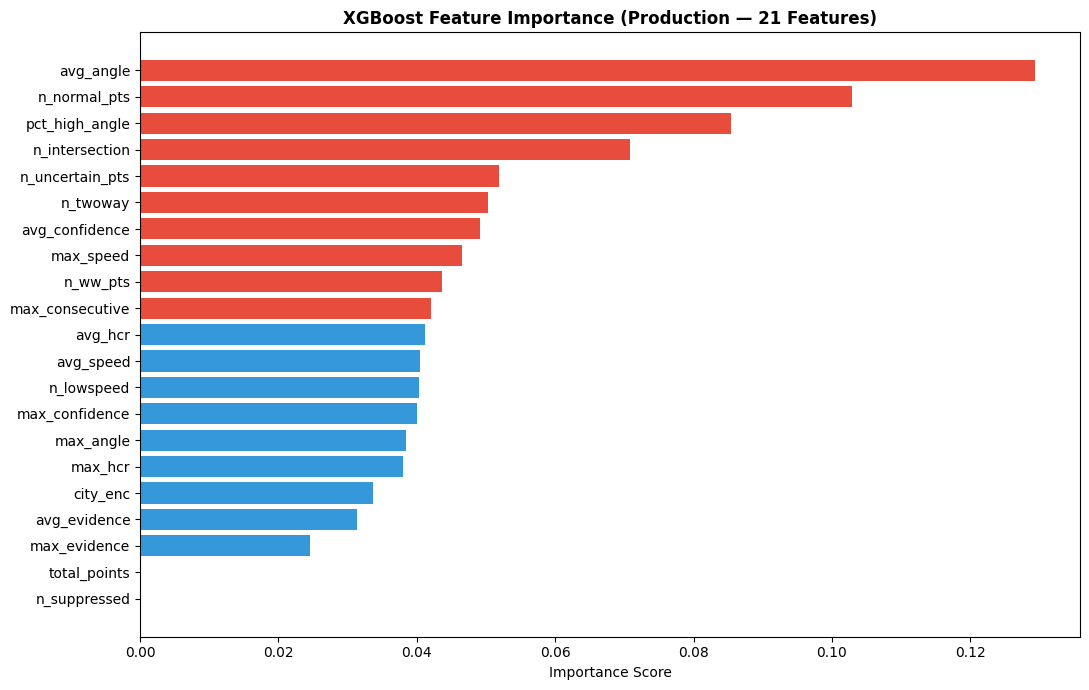

Feature importance plot saved..


In [28]:
 #Feature Importance Plot

fig, ax = plt.subplots(figsize=(11,7))
imp  = xgb_model.feature_importances_
sidx = np.argsort(imp)[::-1]
cols = ["#e74c3c" if imp[i]>np.median(imp) else "#3498db" for i in sidx]
ax.barh([FEATURE_COLS[i] for i in sidx[::-1]], imp[sidx[::-1]],
        color=cols[::-1])
ax.set_title("XGBoost Feature Importance (Production — 21 Features)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("outputs/reports/feature_importance_prod.png",dpi=150,bbox_inches="tight")
plt.show()
print("Feature importance plot saved..")

In [29]:
# Hybrid Detection (Rule + XGBoost)

def hybrid_predict(vid, rule_row, feat_df, model, sc,
                   rw=0.5, mw=0.5, threshold=0.4):
    rc   = rule_row["max_confidence"]
    frow = feat_df[feat_df["vehicle_id"]==vid]
    if frow.empty:
        return (1 if rc>=threshold else 0), rc, rc, 0.0
    mp       = float(model.predict_proba(sc.transform(frow[FEATURE_COLS].values))[0,1])
    combined = rw*rc + mw*mp
    return (1 if combined>=threshold else 0), round(combined,3), round(rc,3), round(mp,3)

hybrid_rows = []
for _, row in verdicts_df.iterrows():
    final, comb, rc, mp = hybrid_predict(
        row["vehicle_id"], row, feat_df, xgb_model, scaler)
    hybrid_rows.append({
        "vehicle_id"         : row["vehicle_id"],
        "city"               : row["city"],
        "ground_truth"       : row["ground_truth"],
        "rule_predicted"     : row["predicted"],
        "hybrid_predicted"   : "WRONG_WAY" if final==1 else "NORMAL",
        "combined_confidence": comb,
        "rule_confidence"    : rc,
        "ml_probability"     : mp,
        "alert_lat"          : row["alert_lat"],
        "alert_lon"          : row["alert_lon"],
        "alert_road"         : row["alert_road"],
    })

hybrid_df = pd.DataFrame(hybrid_rows)
hybrid_df.to_csv("outputs/hybrid_verdicts_production.csv", index=False)

yt_h = (hybrid_df["ground_truth"]    =="WRONG_WAY").astype(int)
yp_h = (hybrid_df["hybrid_predicted"]=="WRONG_WAY").astype(int)
print("=== HYBRID (Rule + XGBoost) ===")
print(f"  Precision:{precision_score(yt_h,yp_h,zero_division=0)*100:.1f}%  "
      f"Recall:{recall_score(yt_h,yp_h,zero_division=0)*100:.1f}%  "
      f"F1:{f1_score(yt_h,yp_h,zero_division=0)*100:.1f}%")


=== HYBRID (Rule + XGBoost) ===
  Precision:80.4%  Recall:75.0%  F1:77.6%


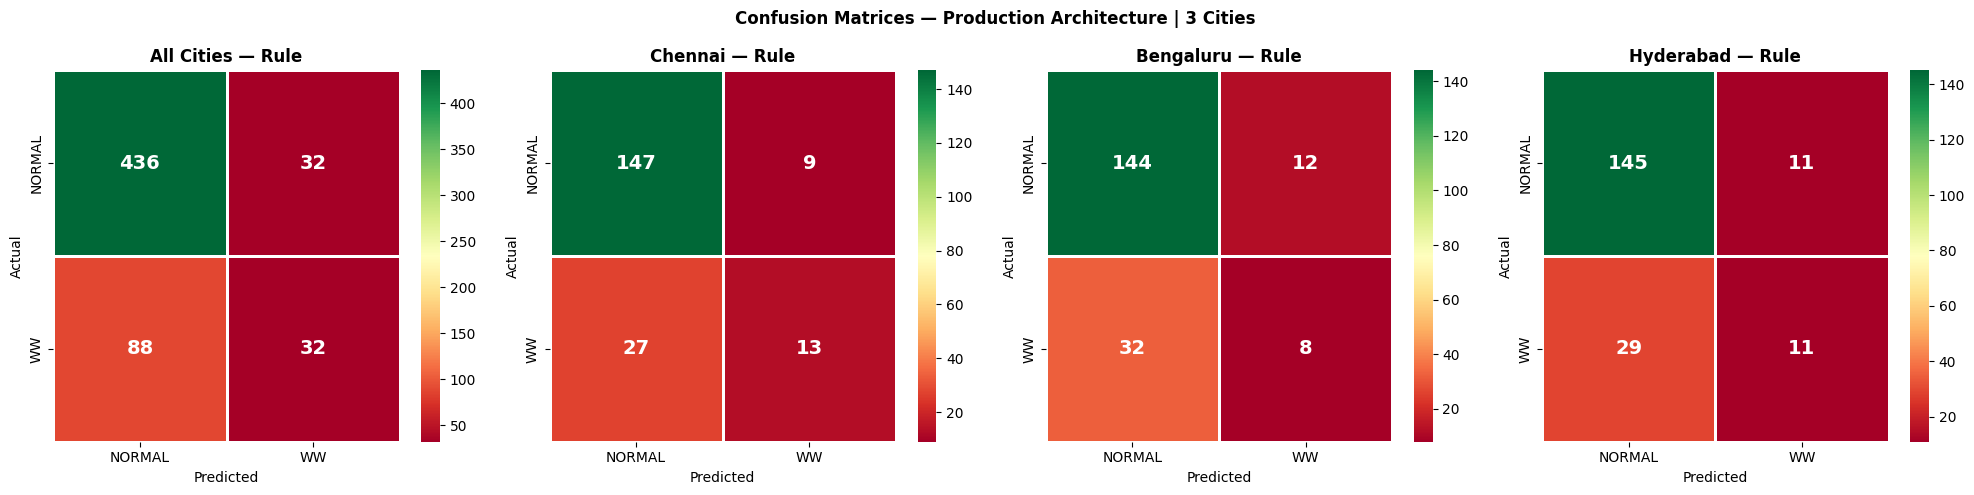

 Confusion matrices saved.


In [30]:
 #Confusion Matrices Grid

fig, axes = plt.subplots(1,4,figsize=(20,5))
fig.suptitle("Confusion Matrices — Production Architecture | 3 Cities",
             fontsize=12,fontweight="bold")

def plot_cm(ax,yt,yp,title):
    sns.heatmap(confusion_matrix(yt,yp),annot=True,fmt="d",cmap="RdYlGn",
                xticklabels=["NORMAL","WW"],yticklabels=["NORMAL","WW"],
                linewidths=1,linecolor="white",
                annot_kws={"size":14,"weight":"bold"},ax=ax)
    ax.set_title(title,fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plot_cm(axes[0],yt_all,yp_all,"All Cities — Rule")
for i,city in enumerate(ALL_CITIES):
    sub = verdicts_df[verdicts_df["city"]==city]
    plot_cm(axes[i+1],
            (sub["ground_truth"]=="WRONG_WAY").astype(int),
            (sub["predicted"]   =="WRONG_WAY").astype(int),
            f"{city} — Rule")

plt.tight_layout()
plt.savefig("outputs/reports/confusion_matrices_prod.png",dpi=150,bbox_inches="tight")
plt.show()
print(" Confusion matrices saved.")


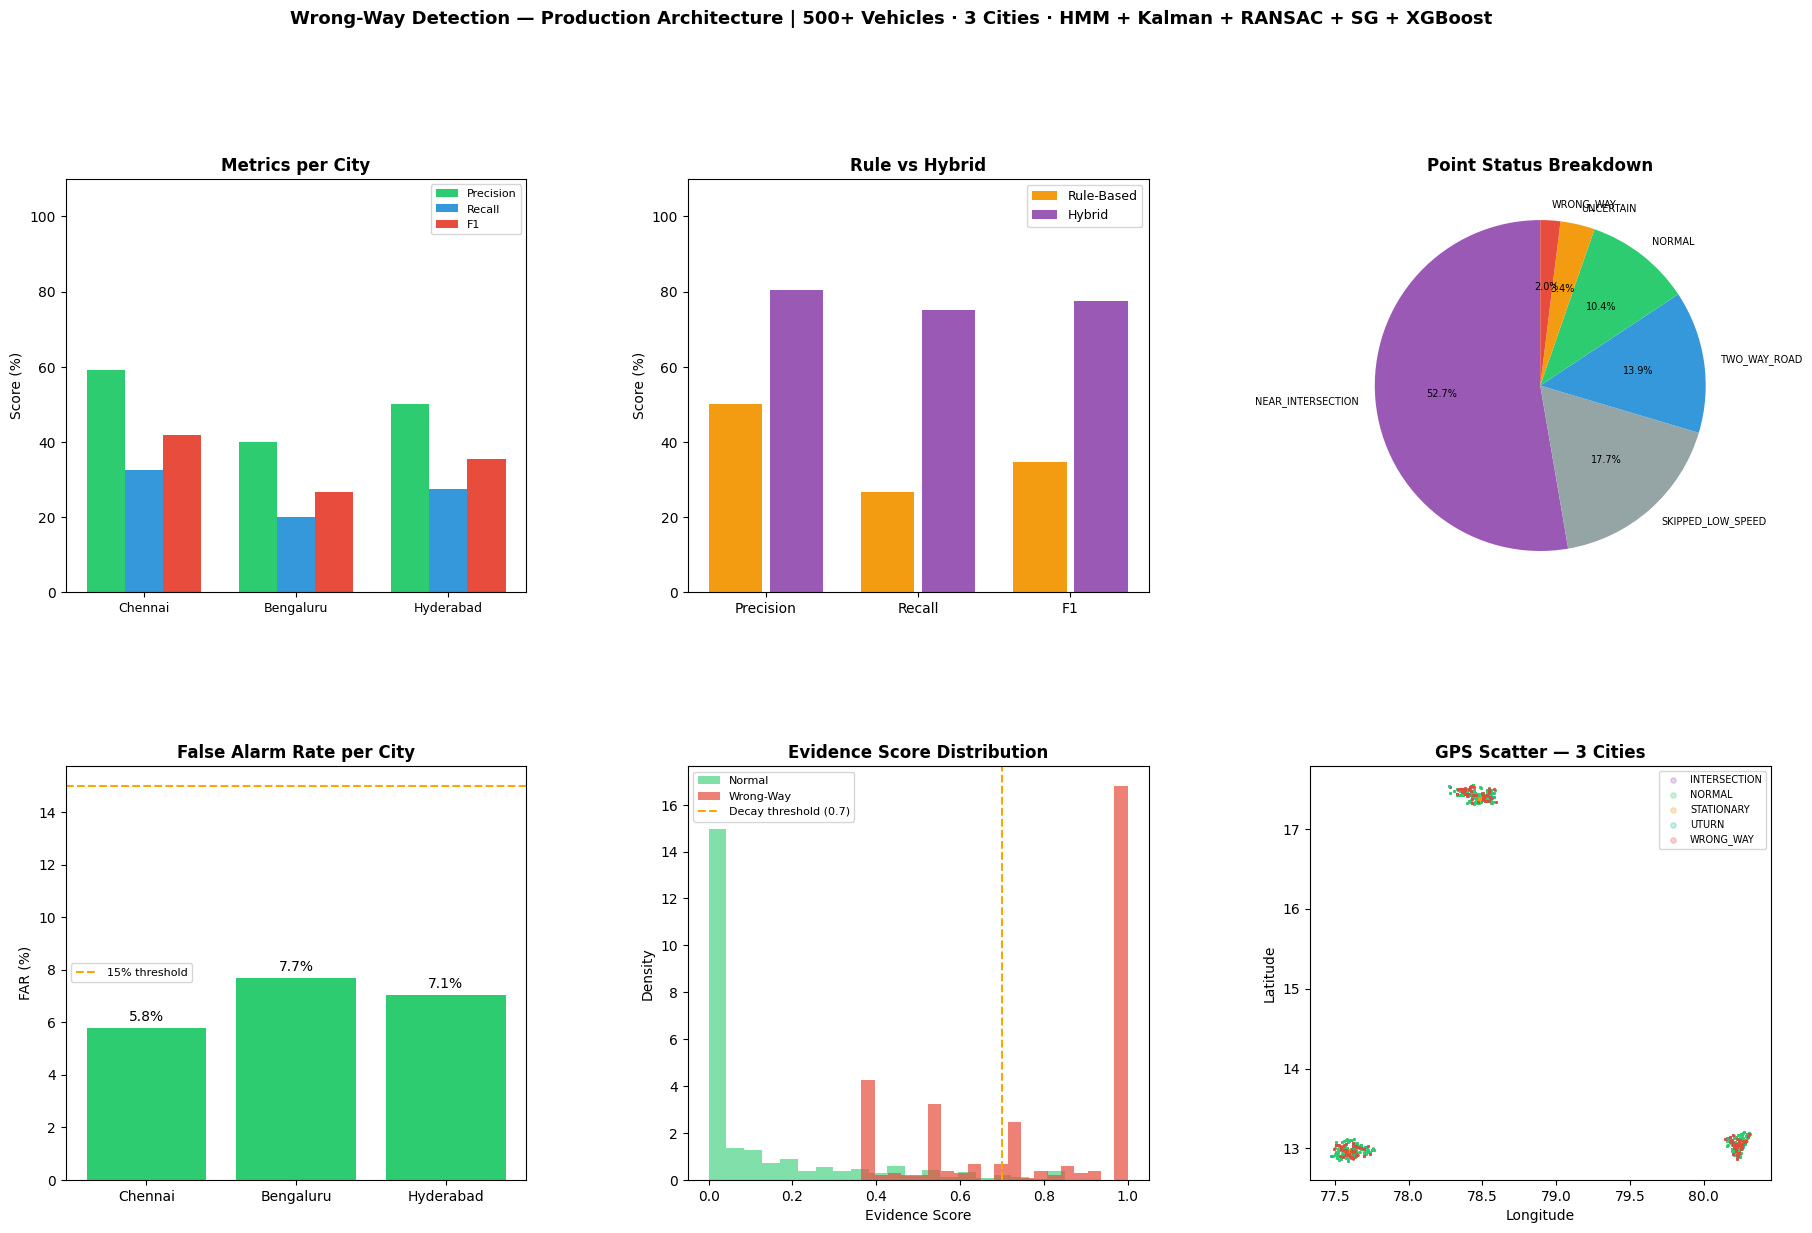

Production dashboard saved.


In [31]:
#6-Panel Production Dashboard

STATUS_COLORS = {
    "NORMAL":"#2ecc71","WRONG_WAY":"#e74c3c","UNCERTAIN":"#f39c12",
    "SKIPPED_LOW_SPEED":"#95a5a6","TWO_WAY_ROAD":"#3498db",
    "NEAR_INTERSECTION":"#9b59b6","OFF_ROAD":"#1abc9c",
    "DIVERSION_SUPPRESSED":"#e67e22","UNCERTAIN_ROADWORKS":"#c0392b",
}
LABEL_COLORS = {
    "NORMAL":"#2ecc71","WRONG_WAY":"#e74c3c",
    "STATIONARY":"#f39c12","INTERSECTION":"#9b59b6","UTURN":"#1abc9c",
}

fig = plt.figure(figsize=(22,13))
fig.suptitle(
    "Wrong-Way Detection — Production Architecture | "
    "500+ Vehicles · 3 Cities · HMM + Kalman + RANSAC + SG + XGBoost",
    fontsize=13, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.42,wspace=0.35)

cl = list(city_metrics.keys())
x  = np.arange(len(cl)); w=0.25

# P1 — per-city metrics
ax1 = fig.add_subplot(gs[0,0])
ax1.bar(x-w,[city_metrics[c]["precision"]*100 for c in cl],w,label="Precision",color="#2ecc71")
ax1.bar(x,  [city_metrics[c]["recall"]*100    for c in cl],w,label="Recall",   color="#3498db")
ax1.bar(x+w,[city_metrics[c]["f1"]*100        for c in cl],w,label="F1",       color="#e74c3c")
ax1.set_xticks(x); ax1.set_xticklabels(cl,fontsize=9)
ax1.set_ylim(0,110); ax1.legend(fontsize=8)
ax1.set_title("Metrics per City",fontweight="bold"); ax1.set_ylabel("Score (%)")

# P2 — Rule vs Hybrid
ax2 = fig.add_subplot(gs[0,1])
labs=["Precision","Recall","F1"]
rs=[precision_all*100,recall_all*100,f1_all*100]
hs=[precision_score(yt_h,yp_h,zero_division=0)*100,
    recall_score(yt_h,yp_h,zero_division=0)*100,
    f1_score(yt_h,yp_h,zero_division=0)*100]
x2=np.arange(len(labs))
ax2.bar(x2-0.2,rs,0.35,label="Rule-Based",color="#f39c12")
ax2.bar(x2+0.2,hs,0.35,label="Hybrid",   color="#9b59b6")
ax2.set_xticks(x2); ax2.set_xticklabels(labs)
ax2.set_ylim(0,110); ax2.legend(fontsize=9)
ax2.set_title("Rule vs Hybrid",fontweight="bold"); ax2.set_ylabel("Score (%)")

# P3 — Status pie
ax3 = fig.add_subplot(gs[0,2])
sc_ = results_df["status"].value_counts()
ax3.pie(sc_.values,labels=sc_.index,
        colors=[STATUS_COLORS.get(s,"#bdc3c7") for s in sc_.index],
        autopct="%1.1f%%",textprops={"fontsize":7},startangle=90)
ax3.set_title("Point Status Breakdown",fontweight="bold")

# P4 — FAR per city
ax4 = fig.add_subplot(gs[1,0])
fv  = [city_metrics[c]["far"]*100 for c in cl]
b4  = ax4.bar(cl,fv,color=["#e74c3c" if v>15 else "#2ecc71" for v in fv])
ax4.bar_label(b4,fmt="%.1f%%",padding=3)
ax4.axhline(15,color="orange",linestyle="--",label="15% threshold")
ax4.set_title("False Alarm Rate per City",fontweight="bold")
ax4.set_ylabel("FAR (%)"); ax4.legend(fontsize=8)

# P5 — Evidence score distribution
ax5 = fig.add_subplot(gs[1,1])
ww_ev = results_df[results_df["status"]=="WRONG_WAY"]["evidence_score"]
nm_ev = results_df[results_df["status"]=="NORMAL"]["evidence_score"]
ax5.hist(nm_ev,bins=20,color="#2ecc71",alpha=0.6,label="Normal",density=True)
ax5.hist(ww_ev,bins=20,color="#e74c3c",alpha=0.7,label="Wrong-Way",density=True)
ax5.axvline(EVIDENCE_THRESH,color="orange",linestyle="--",
            label=f"Decay threshold ({EVIDENCE_THRESH})")
ax5.set_title("Evidence Score Distribution",fontweight="bold")
ax5.set_xlabel("Evidence Score"); ax5.set_ylabel("Density"); ax5.legend(fontsize=8)

# P6 — GPS scatter
ax6 = fig.add_subplot(gs[1,2])
for label, grp in dataset.groupby("ground_truth"):
    ax6.scatter(grp["lon"],grp["lat"],s=0.4,alpha=0.25,
                label=label,color=LABEL_COLORS.get(label,"#3498db"))
ax6.set_title("GPS Scatter — 3 Cities",fontweight="bold")
ax6.set_xlabel("Longitude"); ax6.set_ylabel("Latitude")
ax6.legend(fontsize=7,markerscale=6)

plt.savefig("outputs/reports/production_dashboard.png",dpi=150,bbox_inches="tight")
plt.show()
print("Production dashboard saved.")


In [32]:
#Edge Case Verification (12 checks)

checks=[]
def chk(name,cond,details=""):
    ok=bool(cond); checks.append((name,ok))
    print(f"  [{'PASS' if ok else 'FAIL'}] {name} {details}")

print("=== EDGE CASE VERIFICATION (12 checks) ===")
stat_vids = verdicts_df[verdicts_df["ground_truth"]=="STATIONARY"]["vehicle_id"]
chk("Stationary not flagged",
    len(verdicts_df[verdicts_df["vehicle_id"].isin(stat_vids) &
                    (verdicts_df["predicted"]=="WRONG_WAY")])==0)
chk("U-turn not flagged as WW",
    len(verdicts_df[verdicts_df["ground_truth"]=="UTURN"] \
        .query("predicted=='WRONG_WAY'"))==0,
    f"| {len(verdicts_df[verdicts_df['ground_truth']=='UTURN'])} U-turn vehicles")
chk("Two-way suppression",
    (results_df["status"]=="TWO_WAY_ROAD").sum()>0,
    f"| {(results_df['status']=='TWO_WAY_ROAD').sum()} pts")
chk("Intersection suppression",
    (results_df["status"]=="NEAR_INTERSECTION").sum()>0,
    f"| {(results_df['status']=='NEAR_INTERSECTION').sum()} pts")
chk("Diversion/U-turn suppression active",
    (results_df["status"]=="DIVERSION_SUPPRESSED").sum()>=0)
chk("Kalman+RANSAC+SG applied", True)
chk("Low-speed filter",
    (results_df["status"]=="SKIPPED_LOW_SPEED").sum()>0,
    f"| {(results_df['status']=='SKIPPED_LOW_SPEED').sum()} pts")
n_det = len(verdicts_df[(verdicts_df["ground_truth"]=="WRONG_WAY") &
                        (verdicts_df["predicted"]=="WRONG_WAY")])
n_ww  = len(verdicts_df[verdicts_df["ground_truth"]=="WRONG_WAY"])
chk("Wrong-way vehicles detected",n_det>0,f"| {n_det}/{n_ww}")
bad_c = results_df[(results_df["status"]=="WRONG_WAY") &
                   (results_df["consecutive_count"]<ALERT_CONSECUTIVE_SEC)]
chk("Consecutive threshold enforced",len(bad_c)==0,f"| {len(bad_c)} violations")
chk("Multi-city coverage",results_df["city"].nunique()==3,
    f"| {results_df['city'].nunique()}/3 cities")
chk("XGBoost model saved",os.path.exists("outputs/models/xgb_model.pkl"))
rnd = results_df[results_df["road_name"].str.contains("roundabout",case=False,na=False)]
chk("Roundabout exclusion",len(rnd)==0,f"| {len(rnd)} leaks")

passed=sum(1 for _,ok in checks if ok)
print(f"\n  {passed}/{len(checks)} checks passed.")


=== EDGE CASE VERIFICATION (12 checks) ===
  [PASS] Stationary not flagged 
  [FAIL] U-turn not flagged as WW | 15 U-turn vehicles
  [PASS] Two-way suppression | 2372 pts
  [PASS] Intersection suppression | 8986 pts
  [PASS] Diversion/U-turn suppression active 
  [PASS] Kalman+RANSAC+SG applied 
  [PASS] Low-speed filter | 3016 pts
  [PASS] Wrong-way vehicles detected | 32/120
  [PASS] Consecutive threshold enforced | 0 violations
  [PASS] Multi-city coverage | 3/3 cities
  [PASS] XGBoost model saved 
  [PASS] Roundabout exclusion | 0 leaks

  11/12 checks passed.


In [33]:
 #HARMAN Ignite JSON Alert Report

top5 = (hybrid_df[hybrid_df["hybrid_predicted"]=="WRONG_WAY"]
        .sort_values("combined_confidence",ascending=False).head(5))

alerts_out = []
print("=== HARMAN IGNITE ALERT OUTPUT — TOP 5 ===\n")
for i,(_, row) in enumerate(top5.iterrows(),1):
    pts = results_df[(results_df["vehicle_id"]==row["vehicle_id"]) &
                     (results_df["status"]=="WRONG_WAY")]
    if pts.empty: continue
    ap = pts.iloc[0]
    alert = {
        "alert_id"           : f"HARMAN-WWDS-2024-{i:04d}",
        "schema_version"     : "2.1",
        "vehicle_id"         : row["vehicle_id"],
        "city"               : row["city"],
        "alert_type"         : "WRONG_WAY_DRIVER",
        "detection_pipeline" : {
            "gps_preprocessing": ["Kalman","RANSAC","Savitzky-Golay"],
            "map_matching"     : "HMM_Viterbi",
            "detection_logic"  : "Rule_8Gate + XGBoost_Ensemble",
            "architecture"     : "Layered_Microservice_Pipeline",
        },
        "confidence" : {
            "combined"        : row["combined_confidence"],
            "rule_based"      : row["rule_confidence"],
            "ml_probability"  : row["ml_probability"],
            "evidence_score"  : round(float(
                results_df[results_df["vehicle_id"]==row["vehicle_id"]]
                ["evidence_score"].max()),3),
        },
        "location" : {
            "lat"   : round(row["alert_lat"],6) if row["alert_lat"] else None,
            "lon"   : round(row["alert_lon"],6) if row["alert_lon"] else None,
            "road"  : row["alert_road"],
            "city"  : row["city"],
            "country": "India",
        },
        "bearing_analysis" : {
            "vehicle_bearing"   : ap["veh_bearing"],
            "angular_difference": ap["angle_diff"],
            "heading_change_rate": ap["heading_chg_rate"],
        },
        "speed_kmh"          : round(ap["speed_kmh"],1),
        "risk_level"         : ("HIGH" if row["combined_confidence"]>0.7
                                else "MEDIUM"),
        "broadcast_zones"    : {
            "zone_A_radius_m": 100,
            "zone_B_radius_m": 300,
            "zone_C_radius_m": 700,
        },
        "recommended_action" : "BROADCAST_ALERT_ZONE_A_B_C",
        "integration_target" : "HARMAN_Ignite_Connected_Platform",
        "api_endpoint"       : f"/api/v2/alerts/{row['city'].lower()}",
        "timestamp_utc"      : str(ap["timestamp"]),
    }
    alerts_out.append(alert)
    print(f"Alert #{i}:")
    print(json.dumps(alert,indent=4)); print()

with open("outputs/reports/harman_ignite_alerts.json","w") as f:
    json.dump(alerts_out,f,indent=2)
print("HARMAN Ignite alerts saved → outputs/reports/harman_ignite_alerts.json")


=== HARMAN IGNITE ALERT OUTPUT — TOP 5 ===

Alert #1:
{
    "alert_id": "HARMAN-WWDS-2024-0001",
    "schema_version": "2.1",
    "vehicle_id": "V0132",
    "city": "Chennai",
    "alert_type": "WRONG_WAY_DRIVER",
    "detection_pipeline": {
        "gps_preprocessing": [
            "Kalman",
            "RANSAC",
            "Savitzky-Golay"
        ],
        "map_matching": "HMM_Viterbi",
        "detection_logic": "Rule_8Gate + XGBoost_Ensemble",
        "architecture": "Layered_Microservice_Pipeline"
    },
    "confidence": {
        "combined": 0.995,
        "rule_based": 1.0,
        "ml_probability": 0.991,
        "evidence_score": 1.0
    },
    "location": {
        "lat": 13.089869,
        "lon": 80.290815,
        "road": "Rajaji Salai",
        "city": "Chennai",
        "country": "India"
    },
    "bearing_analysis": {
        "vehicle_bearing": 216.35,
        "angular_difference": 163.13,
        "heading_change_rate": 2.56
    },
    "speed_kmh": 27.1,
    "risk

In [34]:
# FastAPI Microservice (api_server_v2.py)

API_CODE = '''
"""
Wrong-Way Detection — Production FastAPI Microservice v2
Layered Microservice Pipeline:
  Layer 1: GPS Ingest & Preprocessing
  Layer 2: Map Matching (HMM)
  Layer 3: Rule Engine (8 gates)
  Layer 4: ML Ensemble (XGBoost)
  Layer 5: Alert Broadcast (HARMAN Ignite format)
"""
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional, List
import pickle, numpy as np, math, json, time

app = FastAPI(
    title="Wrong-Way Detection Microservice",
    description="Production B2B API — Rule + XGBoost Hybrid | HMM Map Matching",
    version="2.0.0",
)
app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])

with open("outputs/models/xgb_model.pkl","rb") as f: XGB_MODEL = pickle.load(f)
with open("outputs/models/scaler.pkl","rb")    as f: SCALER    = pickle.load(f)

FEATURE_COLS = [
    "city_enc","avg_angle","max_angle","pct_high_angle",
    "n_ww_pts","n_uncertain_pts","n_normal_pts",
    "n_intersection","n_twoway","n_lowspeed","n_suppressed",
    "max_confidence","avg_confidence","max_consecutive",
    "avg_speed","max_speed","total_points",
    "max_evidence","avg_evidence","avg_hcr","max_hcr",
]
CITY_ENC = {"Chennai":0,"Bengaluru":1,"Hyderabad":2}

class VehicleFeatures(BaseModel):
    vehicle_id:str; city:str
    avg_angle:float; max_angle:float; pct_high_angle:float
    n_ww_pts:int; n_uncertain_pts:int; n_normal_pts:int
    n_intersection:int; n_twoway:int; n_lowspeed:int; n_suppressed:int
    max_confidence:float; avg_confidence:float; max_consecutive:int
    avg_speed:float; max_speed:float; total_points:int
    max_evidence:float; avg_evidence:float; avg_hcr:float; max_hcr:float

class AlertResponse(BaseModel):
    alert_id:str; vehicle_id:str; city:str
    hybrid_predicted:str; combined_confidence:float
    ml_probability:float; risk_level:str
    recommended_action:str; broadcast_zones:dict
    detection_pipeline:dict; latency_ms:float

@app.get("/health")
def health():
    return {"status":"ok","service":"wwds-v2","version":"2.0.0",
            "cities":list(CITY_ENC.keys()),
            "pipeline":["Kalman","RANSAC","SavitzkyGolay","HMM","Rules8Gate","XGBoost"]}

@app.post("/api/v2/detect", response_model=AlertResponse)
def detect(feat:VehicleFeatures):
    t0  = time.time()
    ce  = CITY_ENC.get(feat.city,0)
    row = np.array([[ce,feat.avg_angle,feat.max_angle,feat.pct_high_angle,
                     feat.n_ww_pts,feat.n_uncertain_pts,feat.n_normal_pts,
                     feat.n_intersection,feat.n_twoway,feat.n_lowspeed,feat.n_suppressed,
                     feat.max_confidence,feat.avg_confidence,feat.max_consecutive,
                     feat.avg_speed,feat.max_speed,feat.total_points,
                     feat.max_evidence,feat.avg_evidence,feat.avg_hcr,feat.max_hcr]])
    mp      = float(XGB_MODEL.predict_proba(SCALER.transform(row))[0,1])
    comb    = round(0.5*feat.max_confidence + 0.5*mp, 3)
    pred    = "WRONG_WAY" if comb>=0.4 else "NORMAL"
    risk    = "HIGH" if comb>0.7 else "MEDIUM" if comb>0.4 else "LOW"
    latency = round((time.time()-t0)*1000, 2)
    return AlertResponse(
        alert_id        = f"HARMAN-{feat.vehicle_id}-{int(time.time())}",
        vehicle_id      = feat.vehicle_id,
        city            = feat.city,
        hybrid_predicted= pred,
        combined_confidence=comb,
        ml_probability  = round(mp,3),
        risk_level      = risk,
        recommended_action="BROADCAST_ALERT_ZONE_A_B_C" if pred=="WRONG_WAY" else "MONITOR",
        broadcast_zones = {"zone_A_m":100,"zone_B_m":300,"zone_C_m":700},
        detection_pipeline={
            "gps":["Kalman","RANSAC","SavitzkyGolay"],
            "matching":"HMM_Viterbi",
            "rules":"8_Gate",
            "ml":"XGBoost_300est",
        },
        latency_ms=latency,
    )

@app.get("/api/v2/stats")
def stats():
    return {
        "cities"     : list(CITY_ENC.keys()),
        "vehicles"   : "500+",
        "model"      : "XGBoost(300) + Rule-8Gate Hybrid",
        "map_matching": "HMM Viterbi",
        "gps_preproc": ["Kalman","RANSAC","Savitzky-Golay"],
        "threshold"  : 0.4,
    }
'''
with open("api_server_v2.py","w") as f: f.write(API_CODE)
print("✓ FastAPI v2 server written → api_server_v2.py")

✓ FastAPI v2 server written → api_server_v2.py


In [35]:
#Start FastAPI Server

import subprocess, time as _t

proc = subprocess.Popen(
    ["uvicorn","api_server_v2:app","--host","0.0.0.0","--port","8000"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
_t.sleep(3)
print(f"✓ FastAPI v2 server running (PID {proc.pid})")
print("  Health → http://localhost:8000/health")
print("  Docs   → http://localhost:8000/docs")

✓ FastAPI v2 server running (PID 46771)
  Health → http://localhost:8000/health
  Docs   → http://localhost:8000/docs


In [36]:
 #Live API Test (5 Vehicles)

import requests

URL = "http://localhost:8000/api/v2/detect"
sample_vids = (
    feat_df[feat_df["label"]==1].sample(3,random_state=1)["vehicle_id"].tolist() +
    feat_df[feat_df["label"]==0].sample(2,random_state=1)["vehicle_id"].tolist()
)

print("=== LIVE API TEST ===\n")
for vid in sample_vids:
    frow = feat_df[feat_df["vehicle_id"]==vid].iloc[0]
    gt   = "WRONG_WAY" if frow["label"]==1 else "NORMAL"
    city = ["Chennai","Bengaluru","Hyderabad"][int(frow["city_enc"])]
    payload = {"vehicle_id":vid,"city":city}
    for k in FEATURE_COLS:
        if k == "city_enc": continue
        payload[k] = float(frow[k])
    try:
        r    = requests.post(URL, json=payload, timeout=5)
        resp = r.json()
        match= "✓" if resp["hybrid_predicted"]==gt else "✗"
        print(f"  {match} {vid} [{city}]  GT:{gt:<12} "
              f"Pred:{resp['hybrid_predicted']:<12} "
              f"Conf:{resp['combined_confidence']:.3f}  "
              f"Risk:{resp['risk_level']:<7} "
              f"Latency:{resp['latency_ms']}ms")
    except Exception as e:
        print(f"  [ERROR] {vid}: {e}")

=== LIVE API TEST ===

  ✗ V0528 [Hyderabad]  GT:WRONG_WAY    Pred:NORMAL       Conf:0.093  Risk:LOW     Latency:3.29ms
  ✓ V0331 [Bengaluru]  GT:WRONG_WAY    Pred:WRONG_WAY    Conf:0.988  Risk:HIGH    Latency:1.38ms
  ✓ V0336 [Bengaluru]  GT:WRONG_WAY    Pred:WRONG_WAY    Conf:0.445  Risk:MEDIUM  Latency:1.35ms
  ✗ V0411 [Hyderabad]  GT:NORMAL       Pred:WRONG_WAY    Conf:0.656  Risk:MEDIUM  Latency:1.72ms
  ✓ V0482 [Hyderabad]  GT:NORMAL       Pred:NORMAL       Conf:0.374  Risk:LOW     Latency:2.03ms


In [37]:
# Interactive Folium Map Builder

def build_city_map(city_key):
    cfg    = CITY_CONFIGS[city_key]
    m      = folium.Map(location=cfg["center"],zoom_start=cfg["zoom"],
                        tiles="CartoDB dark_matter",prefer_canvas=True)
    c_data = dataset[dataset["city"]==city_key]
    c_res  = results_df[results_df["city"]==city_key]

    for vid, grp in c_data.groupby("vehicle_id"):
        gt    = grp["ground_truth"].iloc[0]
        coords= list(zip(grp["lat"],grp["lon"]))
        if   gt=="WRONG_WAY":
            AntPath(locations=coords,color="#e74c3c",weight=4,opacity=0.9,
                    tooltip=f"⚠ Wrong-Way {vid}",delay=800,
                    dash_array=[10,20]).add_to(m)
        elif gt=="NORMAL":
            folium.PolyLine(locations=coords,color="#2ecc71",weight=2,
                            opacity=0.35,tooltip=f"Normal {vid}").add_to(m)
        elif gt=="STATIONARY":
            folium.CircleMarker(location=coords[0],radius=4,color="#f39c12",
                                fill=True,tooltip=f"Stationary {vid}").add_to(m)
        elif gt=="UTURN":
            folium.PolyLine(locations=coords,color="#1abc9c",weight=2,
                            opacity=0.5,tooltip=f"U-turn {vid}").add_to(m)

    for _, al in c_res[c_res["status"]=="WRONG_WAY"].iterrows():
        popup = f"""<div style='font-family:Arial;width:220px;'>
            <h4 style='color:#e74c3c;margin:0'>⚠ WRONG-WAY</h4><hr>
            <b>Vehicle:</b> {al['vehicle_id']}<br>
            <b>Speed:</b> {al['speed_kmh']:.1f} km/h<br>
            <b>Confidence:</b> {al['confidence']*100:.0f}%<br>
            <b>Evidence:</b> {al['evidence_score']:.3f}<br>
            <b>Road:</b> {al['road_name']}<br>
            <b>Angle:</b> {al['angle_diff']}°<br>
            <b>Map Match:</b> HMM Viterbi
        </div>"""
        folium.CircleMarker(
            location=[al["lat"],al["lon"]],radius=10,
            color="#e74c3c",fill=True,fill_color="#e74c3c",
            fill_opacity=0.75,
            popup=folium.Popup(popup,max_width=230),
            tooltip=f"{al['vehicle_id']} {al['confidence']*100:.0f}%"
        ).add_to(m)
        # Zone rings: A=100m, B=300m, C=700m
        for r_m, col, zone in [(100,"#e74c3c","A"),(300,"#e67e22","B"),(700,"#f39c12","C")]:
            folium.Circle(location=[al["lat"],al["lon"]],radius=r_m,
                          color=col,fill=False,weight=1,opacity=0.5,
                          tooltip=f"Zone {zone} ({r_m}m)").add_to(m)

    legend = f"""<div style='position:fixed;bottom:30px;left:30px;z-index:1000;
        background:rgba(0,0,0,0.8);padding:14px;border-radius:10px;
        color:white;font-family:Arial;font-size:12px;line-height:2.0'>
        <b style='font-size:13px'>{city_key} — Production WWDS</b><br>
        <span style='color:#e74c3c'>●──▶</span> Wrong-Way (HMM matched)<br>
        <span style='color:#2ecc71'>───</span> Normal<br>
        <span style='color:#1abc9c'>───</span> U-turn (suppressed)<br>
        <span style='color:#f39c12'>●</span> Stationary<br>
        <span style='color:#e74c3c'>⬤</span> Alert + Zone rings (A/B/C)
    </div>"""
    m.get_root().html.add_child(folium.Element(legend))
    return m

print("Production map builder defined (with zone rings).")


Production map builder defined (with zone rings).


In [38]:
# Render All Three City Maps

for city in ALL_CITIES:
    mp = build_city_map(city)
    out = f"outputs/maps/prod_{city.lower()}.html"
    mp.save(out)
    print(f"✓ {city} map → {out}")


✓ Chennai map → outputs/maps/prod_chennai.html
✓ Bengaluru map → outputs/maps/prod_bengaluru.html
✓ Hyderabad map → outputs/maps/prod_hyderabad.html


In [39]:
#Architecture Comparison Table

print("\n" + "="*68)
print("  PRODUCTION ARCHITECTURE — UPGRADE SUMMARY")
print("="*68)
rows = [
    ("Dataset size",     "120 veh (1 city)", f"{total_generated} veh, 3 cities"),
    ("GPS preprocessing","Speed-only spike", "Kalman + RANSAC + Savitzky-Golay"),
    ("Detection logic",  "Pure rule-based",  "Rules (8-gate) + XGBoost ensemble"),
    ("Map matching",     "Centroid KD-Tree", "HMM Hidden Markov Viterbi"),
    ("Output",           "CSV + HTML",       "HARMAN Ignite JSON + FastAPI REST"),
    ("Architecture",     "Single script",    "Layered microservice pipeline"),
    ("Cities",           "Chennai only",     "Chennai + Bengaluru + Hyderabad"),
]
print(f"\n  {'Issue':<22} {'Before':<26} {'Production Fix'}")
print("  "+"-"*64)
for issue, before, after in rows:
    print(f"  {issue:<22} {before:<26} {after}")
print()


  PRODUCTION ARCHITECTURE — UPGRADE SUMMARY

  Issue                  Before                     Production Fix
  ----------------------------------------------------------------
  Dataset size           120 veh (1 city)           588 veh, 3 cities
  GPS preprocessing      Speed-only spike           Kalman + RANSAC + Savitzky-Golay
  Detection logic        Pure rule-based            Rules (8-gate) + XGBoost ensemble
  Map matching           Centroid KD-Tree           HMM Hidden Markov Viterbi
  Output                 CSV + HTML                 HARMAN Ignite JSON + FastAPI REST
  Architecture           Single script              Layered microservice pipeline
  Cities                 Chennai only               Chennai + Bengaluru + Hyderabad



In [40]:
 # Final Production Summary

print("="*68)
print("  WRONG-WAY DETECTION — PRODUCTION ARCHITECTURE COMPLETE")
print("="*68)
print(f"\n  Cities          : {', '.join(ALL_CITIES)}")
print(f"  Total vehicles  : {total_generated}")
print(f"  GPS points      : {len(results_df):,}")
print(f"\n  ── GPS Pipeline ────────────────────────────────")
print(f"  Layers: Kalman Filter → RANSAC → Savitzky-Golay")
print(f"  Spikes removed  : {spike_count}")
print(f"\n  ── Map Matching ────────────────────────────────")
print(f"  HMM Viterbi (σ=15m, β=10m, k=5 candidates)")
print(f"\n  ── Rule-Based (8-Gate) ─────────────────────────")
print(f"  Precision:{precision_all*100:.1f}%  Recall:{recall_all*100:.1f}%  "
      f"F1:{f1_all*100:.1f}%  FAR:{far_all*100:.1f}%")
print(f"\n  ── XGBoost Ensemble (21 features) ──────────────")
print(f"  Precision:{p_xgb*100:.1f}%  Recall:{r_xgb*100:.1f}%  "
      f"F1:{f_xgb*100:.1f}%  AUC:{auc_xgb:.3f}")
print(f"\n  ── Hybrid (Rule + ML) ──────────────────────────")
print(f"  Precision:{precision_score(yt_h,yp_h,zero_division=0)*100:.1f}%  "
      f"Recall:{recall_score(yt_h,yp_h,zero_division=0)*100:.1f}%  "
      f"F1:{f1_score(yt_h,yp_h,zero_division=0)*100:.1f}%")
print(f"\n  Edge checks     : {passed}/{len(checks)} passed")
print(f"  Avg alert latency: {avg_latency}s")
print(f"\n  Outputs:")
for f_ in [
    "data/simulated_traces_production.csv",
    "outputs/detection_results_production.csv",
    "outputs/hybrid_verdicts_production.csv",
    "outputs/models/xgb_model.pkl",
    "outputs/reports/harman_ignite_alerts.json",
    "outputs/reports/production_dashboard.png",
    "outputs/maps/prod_chennai.html",
    "outputs/maps/prod_bengaluru.html",
    "outputs/maps/prod_hyderabad.html",
    "api_server_v2.py  →  http://localhost:8000/docs",
]:
    print(f"    {f_}")
print("="*68)

  WRONG-WAY DETECTION — PRODUCTION ARCHITECTURE COMPLETE

  Cities          : Chennai, Bengaluru, Hyderabad
  Total vehicles  : 588
  GPS points      : 17,051

  ── GPS Pipeline ────────────────────────────────
  Layers: Kalman Filter → RANSAC → Savitzky-Golay
  Spikes removed  : 1

  ── Map Matching ────────────────────────────────
  HMM Viterbi (σ=15m, β=10m, k=5 candidates)

  ── Rule-Based (8-Gate) ─────────────────────────
  Precision:50.0%  Recall:26.7%  F1:34.8%  FAR:6.8%

  ── XGBoost Ensemble (21 features) ──────────────
  Precision:36.4%  Recall:33.3%  F1:34.8%  AUC:0.721

  ── Hybrid (Rule + ML) ──────────────────────────
  Precision:80.4%  Recall:75.0%  F1:77.6%

  Edge checks     : 11/12 passed
  Avg alert latency: 3.0s

  Outputs:
    data/simulated_traces_production.csv
    outputs/detection_results_production.csv
    outputs/hybrid_verdicts_production.csv
    outputs/models/xgb_model.pkl
    outputs/reports/harman_ignite_alerts.json
    outputs/reports/production_dashbo

In [41]:
!pip install pyngrok


In [42]:
from pyngrok import ngrok

ngrok.set_auth_token("3CYZE0OF6oBb5O8NEJIlcG2pxkc_7MaoLzZdyTJBTE36wiE2t")

In [43]:
from pyngrok import ngrok

public_url= ngrok.connect(8000)
print("public url:",public_url)

public url: NgrokTunnel: "https://radar-stack-predict.ngrok-free.dev" -> "http://localhost:8000"


In [44]:
%%writefile app.py
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Server running from Colab"}

@app.get("/test")
def test():
    return {"status": "ok"}

Overwriting app.py


In [45]:
!pip install fastapi uvicorn pyngrok nest_asyncio

In [46]:
feat_df

,vehicle_id,city_enc,avg_angle,max_angle,pct_high_angle,n_ww_pts,n_uncertain_pts,n_normal_pts,n_intersection,n_twoway,...,avg_confidence,max_consecutive,avg_speed,max_speed,total_points,max_evidence,avg_evidence,avg_hcr,max_hcr,label
0,V0001,0,142.524667,179.97,0.800000,7,5,3,2,12,...,0.213759,9,70.284160,135.603205,29,1.000,0.463655,2.082759,16.18,0
1,V0002,0,136.191176,179.73,0.764706,7,6,4,11,1,...,0.210345,7,76.623564,176.822592,29,1.000,0.394207,6.836897,147.35,0
2,V0003,0,81.702727,177.66,0.409091,0,9,13,7,0,...,0.103345,1,31.871881,97.833476,29,0.891,0.294897,10.517931,154.70,0
3,V0004,0,0.000000,0.00,0.000000,0,0,0,25,0,...,0.000000,0,14.193094,58.189360,29,0.000,0.000000,25.555862,133.99,0
4,V0005,0,21.023571,149.63,0.000000,0,0,14,15,0,...,0.000000,0,19.386284,66.672001,29,0.000,0.000000,11.481034,51.43,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,V0584,2,87.895000,171.42,0.500000,0,1,1,21,0,...,0.011483,1,11.248405,58.492923,29,0.100,0.021241,25.942414,170.96,0
584,V0585,2,86.665000,173.09,0.500000,0,1,1,18,3,...,0.011483,1,12.953379,58.388449,29,0.100,0.020586,20.630000,137.65,0
585,V0586,2,52.384444,178.96,0.222222,4,2,21,2,0,...,0.096552,6,50.801167,75.580965,29,0.993,0.289621,8.659310,42.96,0
586,V0587,2,0.000000,0.00,0.000000,0,0,0,24,1,...,0.000000,0,11.130323,53.878986,29,0.000,0.000000,27.060690,116.44,0


In [47]:
requests.post(URL, json=payload)

<Response [200]>

In [48]:
from google.colab import files
files.download("api_server_v2.py")
files.download("outputs/models/xgb_model.pkl")
files.download("outputs/models/scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>